# Classificação — Pré-processamento e Baseline

**Objetivo:** a partir do entendimento construído na EDA (`01_Classificacao_EDA.ipynb`), preparar os dados para modelagem e estabelecer um baseline de referência.

**Dataset:** acidentes em rodovias federais (PRF, 2024). **Alvo:** `com_vitima_fatal` (binário, desbalanceado ~93%/7%).

**Regra de ouro:** o split treino/teste acontece **antes** de qualquer transformação (encoding, escala) para evitar data leakage. As funções de carregamento/preparação ficam centralizadas em `src/data.py` para serem reaproveitadas pelos próximos notebooks.

## 1. Imports

In [1]:
import sys
sys.path.append('..')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.pipeline import Pipeline

from src.data import ALVO, RANDOM_STATE, TEST_SIZE, carregar_dados, construir_preprocessador, separar_x_y

sns.set_theme(style='whitegrid')

## 2. Carregar dados e separar features/alvo

In [2]:
df = carregar_dados()
X, y = separar_x_y(df)
print('X:', X.shape, '| y positivos:', y.mean().round(4))

X: (73156, 16) | y positivos: 0.0714


## 3. Split treino/teste (antes de qualquer transformação)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print('Treino:', X_train.shape, '| positivos:', y_train.mean().round(4))
print('Teste :', X_test.shape, '| positivos:', y_test.mean().round(4))

Treino: (58524, 16) | positivos: 0.0714
Teste : (14632, 16) | positivos: 0.0714


## 4. Baseline ingênuo

Um `DummyClassifier` que sempre prevê a classe majoritária tem *accuracy* alta só por causa do desbalanceamento — é a referência mínima que qualquer modelo real precisa superar (olhando F1/ROC-AUC, não accuracy).

In [4]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print(classification_report(y_test, pred_dummy, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     13588
           1       0.00      0.00      0.00      1044

    accuracy                           0.93     14632
   macro avg       0.46      0.50      0.48     14632
weighted avg       0.86      0.93      0.89     14632



**Comentário:** como esperado, o `DummyClassifier` atinge 93% de accuracy só por prever sempre "sem vítima fatal" — mas o recall e o F1 da classe positiva são **0,00**. Ele nunca acerta um único acidente fatal. Isso confirma que accuracy não serve como métrica de referência aqui; precisão/recall/F1 da classe 1 e ROC-AUC são os números que importam.

## 5. Baseline real: Regressão Logística

`class_weight='balanced'` compensa o desbalanceamento re-ponderando as classes na função de perda, sem precisar reamostrar os dados.

In [5]:
pipeline_baseline = Pipeline([
    ('preprocessador', construir_preprocessador()),
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
])
pipeline_baseline.fit(X_train, y_train)

pred = pipeline_baseline.predict(X_test)
proba = pipeline_baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print('ROC-AUC:', round(roc_auc_score(y_test, proba), 4))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87     13588
           1       0.21      0.72      0.32      1044

    accuracy                           0.78     14632
   macro avg       0.59      0.75      0.60     14632
weighted avg       0.92      0.78      0.83     14632

ROC-AUC: 0.8329


**Comentário:** com `class_weight='balanced'`, a Regressão Logística já supera muito o dummy onde importa: recall da classe 1 sobe de 0,00 para **0,72** (identifica 72% dos acidentes fatais) e o F1 vai a **0,32**, com ROC-AUC de **0,83** (boa capacidade de separar as classes). O preço é a precisão baixa (0,21) — o modelo gera bastante falso positivo, e a accuracy geral cai para 0,78 porque erra mais na classe majoritária. Esse é o trade-off típico de `class_weight='balanced'`: prioriza não deixar passar casos fatais, à custa de mais alarmes falsos. É o baseline de referência que os próximos notebooks (comparação de modelos e otimização) devem superar.

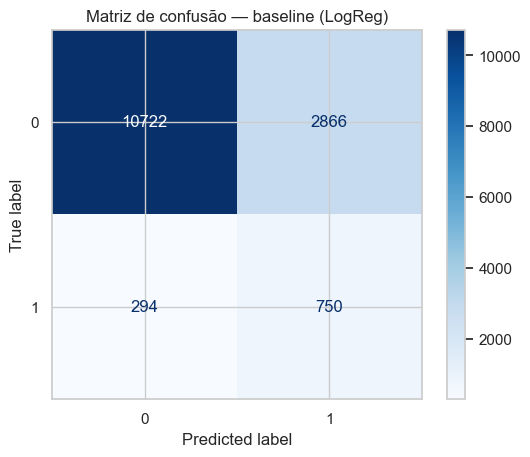

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='Blues')
plt.title('Matriz de confusão — baseline (LogReg)')
plt.savefig('../reports/baseline_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Salvar o baseline

In [7]:
joblib.dump(pipeline_baseline, '../models/baseline_logreg.joblib')

['../models/baseline_logreg.joblib']

## 7. Próximos passos
- Comparar múltiplos modelos com validação cruzada → `03_Comparacao_Modelos.ipynb`
- Otimização bayesiana de hiperparâmetros com Optuna → `04_Otimizacao_Optuna.ipynb`